<a href="https://colab.research.google.com/github/Coldpay018/MNIST-Digit-Classification/blob/main/MNIST_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install opencv-python

In [ ]:
import tensorflow as tf

Tensorflow contains MNIST dataset which is loaded using keras

In [ ]:
mnist = tf.keras.datasets.mnist

Dividing the dataset intro training and testing data

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
 x_train.shape

(60000, 28, 28)

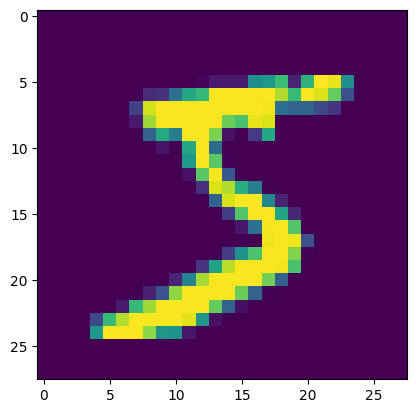

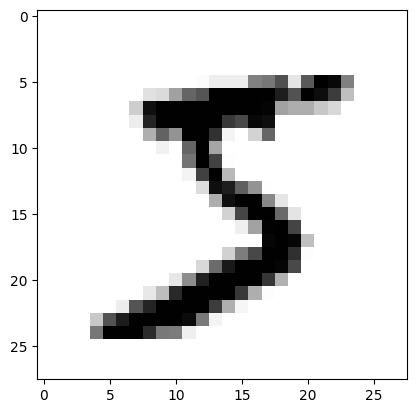

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.show()
plt.imshow(x_train[0], cmap=plt.cm.binary)

In [ ]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [ ]:
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [ ]:
print(y_train[0])

5


In [ ]:
import numpy as np
IMG_SIZE = 28
x_trainr = np.asarray(x_train).reshape(-1,IMG_SIZE,IMG_SIZE,1)
x_testr = np.asarray(x_test).reshape(-1,IMG_SIZE, IMG_SIZE, 1)
print("Training sample dimension: ",x_trainr.shape)
print("Testing sample dimension: ", x_testr.shape)

Training sample dimension:  (60000, 28, 28, 1)
Testing sample dimension:  (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [ ]:
model = Sequential()
model.add(Conv2D(64, (3,3), padding="same", input_shape = x_trainr.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding="same"))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation("relu"))

model.add(Dense(32))
model.add(Activation("relu"))

model.add(Dense(10))
model.add(Activation("softmax"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,834 (444.66 KB)

 Trainable params: 113,834 (444.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [ ]:
model.fit(x_trainr, y_train, epochs=5, validation_split = 0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 121s 79ms/step - accuracy: 0.8564 - loss: 0.4293 - val_accuracy: 0.9819 - val_loss: 0.0588
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 143s 80ms/step - accuracy: 0.9822 - loss: 0.0550 - val_accuracy: 0.9830 - val_loss: 0.0567
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 139s 78ms/step - accuracy: 0.9879 - loss: 0.0372 - val_accuracy: 0.9873 - val_loss: 0.0387
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.9919 - loss: 0.0261 - val_accuracy: 0.9898 - val_loss: 0.0347
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 121s 81ms/step - accuracy: 0.9930 - loss: 0.0201 - val_accuracy: 0.9898 - val_loss: 0.0332


In [ ]:
test_loss, test_acc = model.evaluate(x_testr, y_test)
print("Test Loss on 10,000 test samples", test_loss)
print("Test Accuracy on 10,000 test samples", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9903 - loss: 0.0316
Test Loss on 10,000 test samples 0.02636432833969593
Test Accuracy on 10,000 test samples 0.9922000169754028


In [ ]:
predictions = model.predict(x_testr)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


In [ ]:
print(predictions)

[[2.02639350e-09 5.10847656e-07 3.89079588e-07 ... 9.99850750e-01
  2.95202881e-07 1.40923032e-04]
 [1.34612206e-08 2.80739670e-07 9.99998391e-01 ... 2.52122079e-09
  2.14577267e-09 3.83745362e-11]
 [5.60076023e-06 9.99545395e-01 3.31914134e-06 ... 1.19726465e-04
  7.91900402e-06 4.13654707e-05]
 ...
 [2.67184755e-12 3.35184747e-09 7.93993815e-10 ... 2.07187810e-07
  1.50961499e-09 1.47095713e-08]
 [4.69622172e-08 1.61255298e-09 1.60821217e-10 ... 6.54315224e-09
  3.47299647e-06 1.45953277e-06]
 [7.56387635e-06 9.08574993e-09 1.19414656e-08 ... 5.93266680e-09
  2.64600857e-07 6.13742701e-09]]


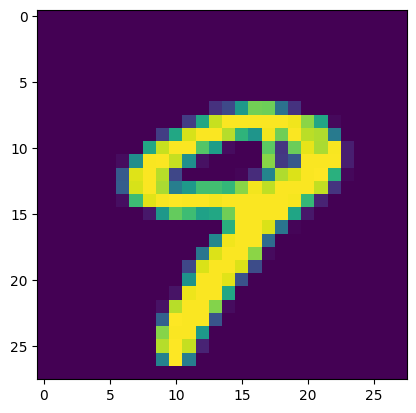

In [ ]:
plt.imshow(x_testr[9])

In [ ]:
print(np.argmax(predictions[9]))

9


In [ ]:
print(np.argmax(predictions[128]))

8


In [ ]:
import cv2

In [ ]:
img = cv2.imread('/content/Screenshot 2026-02-15 162740.png')
img.shape

(713, 630, 3)

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
gray.shape

(713, 630)

In [ ]:
resized = cv2.resize(gray, (28,28), interpolation = cv2.INTER_AREA)

In [ ]:
print(resized)

[[  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
    1   1   1   1   1   1   1   1   1   1]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  10  48  59  59  54  21   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  38 161 247 255 255 255 255 255 230 160
   50   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 122 250 255 255 255 255 255 255 255 255 255
  255 224  56   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 101 255 255 242 135  44  13  12  28  71 131 231
  255 255 130   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 199 255 234  33   0   0   0   0   0   0   0  13
  255 255 130   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 239 255 181   0   0   0   0   0   0   0   0   3
  251 255 150   0   0   0   0   0   0   0]
 [  0   0   0   0   0   6 255 255 144   0   0   0   0   0   0   

In [ ]:
resized = resized.astype("float32") / 255.0


In [ ]:
newimg = np.array(resized).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

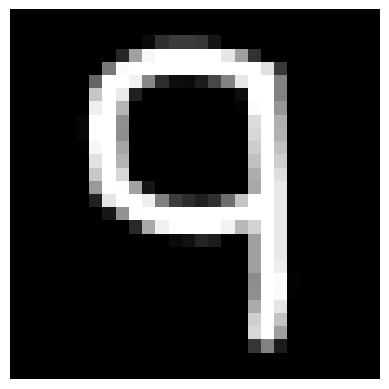

In [ ]:
plt.imshow(newimg[0,:,:,0], cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
newimg.shape

(1, 28, 28, 1)

In [ ]:
predictions = model.predict(newimg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
print(np.argmax(predictions))

9
